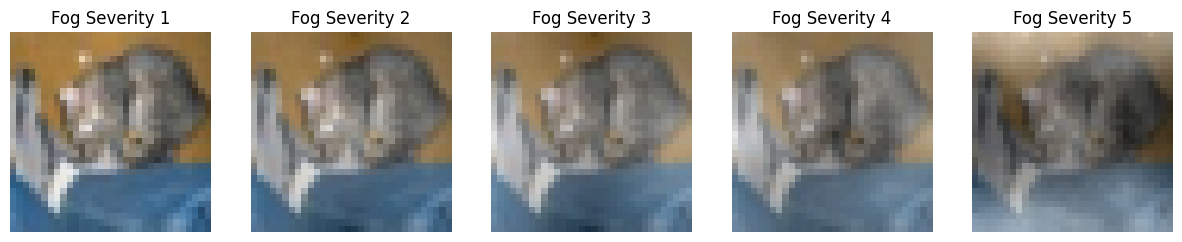

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Load sample data
images = np.load('../data/CIFAR-10-C/fog.npy') # (50000, 32, 32, 3)
labels = np.load('../data/CIFAR-10-C/labels.npy')

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    idx = i * 10000 # Jump to each severity level
    axes[i].imshow(images[idx])
    axes[i].set_title(f"Fog Severity {i+1}")
    axes[i].axis('off')
plt.show()

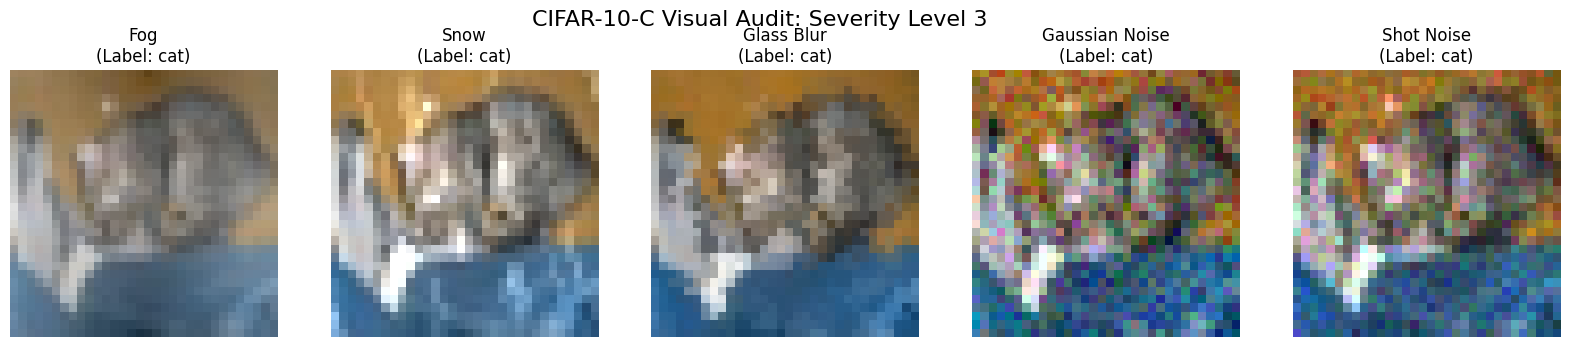

C:\Users\dange\AppData\Local\Temp\ipykernel_47288\2432058085.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=counts, palette='viridis')


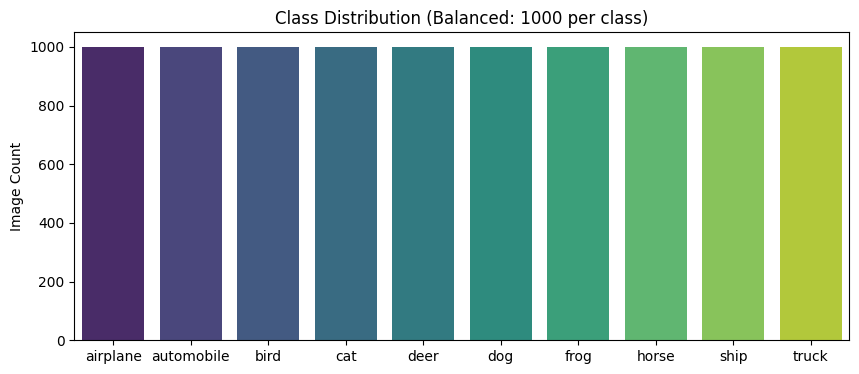

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualize the 15 Corruptions (Severity 3)
corruptions = ['fog', 'snow', 'glass_blur', 'gaussian_noise', 'shot_noise'] # example list
labels = np.load('../data/CIFAR-10-C/labels.npy')
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, name in enumerate(corruptions):
    data = np.load(f'../data/CIFAR-10-C/{name}.npy')
    # Severity 3 starts at index 20,000
    img = data[20000] 
    label = labels[20000]
    axes[i].imshow(img)
    axes[i].set_title(f"{name.replace('_', ' ').title()}\n(Label: {class_names[label]})")
    axes[i].axis('off')

plt.suptitle("CIFAR-10-C Visual Audit: Severity Level 3", fontsize=16)
plt.show()

# 2. Verify Class Distribution
unique, counts = np.unique(labels[:10000], return_counts=True)
plt.figure(figsize=(10, 4))
sns.barplot(x=class_names, y=counts, palette='viridis')
plt.title("Class Distribution (Balanced: 1000 per class)")
plt.ylabel("Image Count")
plt.show()

"We audited the CIFAR-10-C dataset to ensure class balance. "
"Notice how 'Fog' obscures global shapes while 'Gaussian Noise' attacks individual pixel values"
"-this distinction is why we hypothesize the ViT will outperform the CNN on the former."